In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# カップリング解析: チャンネル間伝達経路の推定

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_coupling_analysis.ipynb)


このケーススタディは legacy の PEM injection notebook を公開 docs 用に整理したものです。出力は **結合関数** で、witness チャンネルの雑音が target にどう投影されるかを周波数ごとに推定します。

ただし、この推定は伝達経路のモデルであって、物理機構そのものを証明するものではありません。

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

from gwexpy.analysis import PercentileThreshold, SigmaThreshold, estimate_coupling
from gwexpy.noise.asd import from_pygwinc
from gwexpy.noise.wave import from_asd
from gwexpy.timeseries import TimeSeries, TimeSeriesDict

fs = 2048
duration = 32
t = np.linspace(0, duration, duration * fs, endpoint=False)

# Build background and injection states so the injected witness excess can be distinguished from the nominal detector background.
asd_target = from_pygwinc("aLIGO", fmin=3.0, fmax=fs / 2, df=1.0 / duration, quantity="strain")
asd_target.name = "L0:CAL-DARM_STRAIN"
wit_name = "L0:PEM-VOLT_GND"
wit_bkg = TimeSeries(np.random.normal(0, 1.0, len(t)), t0=0, sample_rate=fs, unit=u.V, name=wit_name)
wit_inj = TimeSeries(np.random.normal(0, 1.0, len(t)), t0=duration, sample_rate=fs, unit=u.V, name=wit_name)
wit_inj += TimeSeries(np.random.normal(0, 20, len(t)), t0=duration, sample_rate=fs, unit=u.V, name=wit_name).bandpass(20, 600)

cf_true = 2e-23 * asd_target.unit * u.Hz**0.5 / wit_bkg.unit
data_bkg = TimeSeriesDict({asd_target.name: from_asd(asd_target, duration, fs, t0=0).highpass(6).notch(8) + cf_true * wit_bkg, wit_bkg.name: wit_bkg})
data_inj = TimeSeriesDict({asd_target.name: from_asd(asd_target, duration, fs, t0=duration).highpass(6).notch(8) + cf_true * wit_inj, wit_inj.name: wit_inj})


## 1. 結合関数を推定する

結合関数は target の excess と witness の excess を比で見ています。target 側に有意な excess が出なければ、推定値ではなく upper limit を返す帯域もあります。

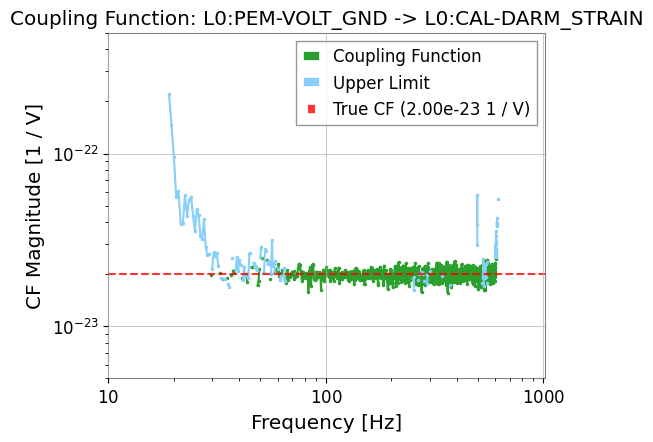

In [3]:
result = estimate_coupling(data_inj, data_bkg, fftlength=2.0, witness=wit_name)

result.plot_cf()
plt.axhline(cf_true.value, color="red", linestyle="--", alpha=0.8, label=f"True CF ({cf_true:.2e})")
plt.ylim(5e-24, 5e-22)
plt.xlim(10, 1020)
plt.legend()
plt.show()


## 2. しきい値戦略を変えて比べる

しきい値の選び方を変えると、どこまで保守的に coupling を見積もるかが変わります。注入線が弱い帯域ほど、その違いが効きます。

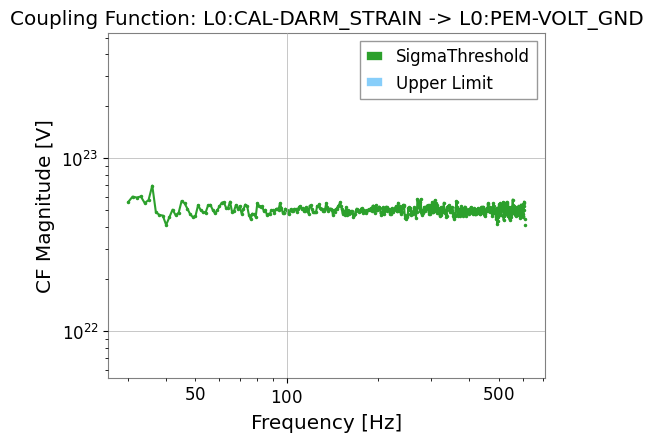

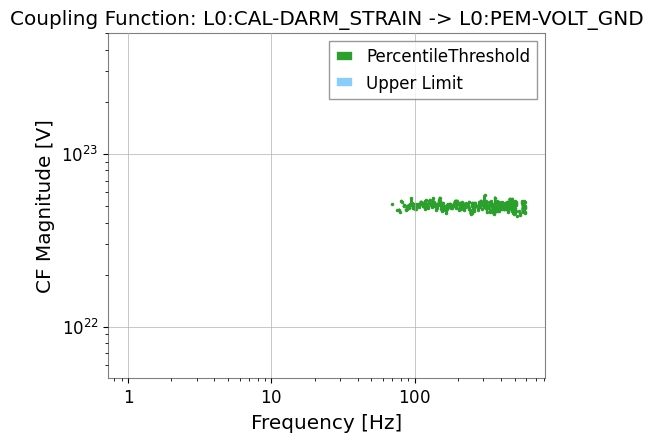

In [4]:
strategy_sigma = SigmaThreshold(sigma=5.0)
strategy_pct = PercentileThreshold(percentile=95, factor=2.0)

result_sigma = estimate_coupling(data_inj, data_bkg, fftlength=1.0, threshold_witness=strategy_sigma)
result_pct = estimate_coupling(data_inj, data_bkg, fftlength=1.0, threshold_witness=strategy_pct)

result_sigma.plot_cf(label="SigmaThreshold")
result_pct.plot_cf(label="PercentileThreshold")
plt.legend()
plt.show()
